# Setup

In [1]:
import sys, os
from dotenv import load_dotenv

IN_COLAB = ('google.colab' in sys.modules)

if IN_COLAB:
    from google.colab import drive, userdata
    drive.mount('/content/drive')

    BASE_PATH = '/content/drive/MyDrive/python/text-autocomplete-rnn'

    sys.path.insert(0, BASE_PATH)

    os.environ['CLEARML_KEY'] = userdata.get('CLEARML_KEY')
    os.environ['CLEARML_SECRET'] = userdata.get('CLEARML_SECRET')
else:
    BASE_PATH = os.getcwd()
    load_dotenv()

In [2]:
import datetime
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import yaml
from collections import Counter
from torch.optim import Adam
from torch.utils.data import random_split
from transformers import BertTokenizerFast, pipeline

from src import (data_utils, model_scoring, monitoring,
                 seq2seq_model, train_utils)
from src.next_token_dataset import NextTokenDataset, next_token_data_loader

/Users/okarpunina/projects/python/ya-dl-nlp/text-autocomplete-rnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

torch.manual_seed(42) 

config_file_path = os.path.join(BASE_PATH, 'configs/config.yaml')

with open(config_file_path, 'r') as file:
    config = yaml.safe_load(file)

ORIGINAL_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], config['dataset']['original_filename'])

basename = os.path.basename(config['dataset']['original_filename'])
DATASET_BASENAME = os.path.splitext(basename)[0]

PREPROCESSED_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_preprocessed.csv')
TRAIN_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_train.csv')
VAL_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_val.csv')
TEST_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_test.csv')

MODEL_DIR = os.path.join(BASE_PATH, config['model']['dir'])

MAX_SEQ_LENGTH = 5

monitoring.init_clearml(config['clearml'])



Using cpu device
ClearML disabled


# Data preprocessing

In [4]:
if not os.path.exists(ORIGINAL_DATASET_PATH):
    urllib.request.urlretrieve(config['dataset']['source'], ORIGINAL_DATASET_PATH)

In [5]:
if not os.path.exists(PREPROCESSED_DATASET_PATH):
    dataset = data_utils.load_data(ORIGINAL_DATASET_PATH)

    preprocessed = [data_utils.clear_text(line) for line in dataset]
    preprocessed = [line for line in preprocessed if line != '']

    data_utils.store_data(preprocessed, PREPROCESSED_DATASET_PATH)

    dataset = preprocessed
else:
    dataset = np.array(data_utils.load_data(PREPROCESSED_DATASET_PATH))

In [6]:
if (not os.path.exists(TRAIN_DATASET_PATH) or 
    not os.path.exists(VAL_DATASET_PATH) or 
    not os.path.exists(VAL_DATASET_PATH)):

    val_size = int(len(dataset) * 0.1)
    test_size = val_size
    train_size = len(dataset) - val_size - test_size

    torch.manual_seed(42)
    train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

    data_utils.store_data(train_data, TRAIN_DATASET_PATH)
    data_utils.store_data(val_data, VAL_DATASET_PATH)
    data_utils.store_data(test_data, TEST_DATASET_PATH)
else:
    train_data = data_utils.load_data(TRAIN_DATASET_PATH)
    val_data = data_utils.load_data(VAL_DATASET_PATH)
    test_data = data_utils.load_data(TEST_DATASET_PATH)

max_examples = config['dataset']['max_examples']
if max_examples > 0:
    train_data = train_data.dataset[:max_examples] if isinstance(train_data, torch.utils.data.dataset.Subset) else train_data[:max_examples]
    val_data = val_data.dataset[:max_examples] if isinstance(val_data, torch.utils.data.dataset.Subset) else val_data[:max_examples]
    test_data = test_data.dataset[:max_examples] if isinstance(test_data, torch.utils.data.dataset.Subset) else test_data[:max_examples]

print(f'Train size: {len(train_data)}')
print(f'Val size: {len(val_data)}')
print(f'Test size: {len(test_data)}')

Train size: 1000
Val size: 1000
Test size: 1000


# Data Exploration

Всего примеров: 1596938
Статистика по количеству строк:
Среднее: 12.78
Медиана: 12.00
5%: 3.00
95%: 25.00


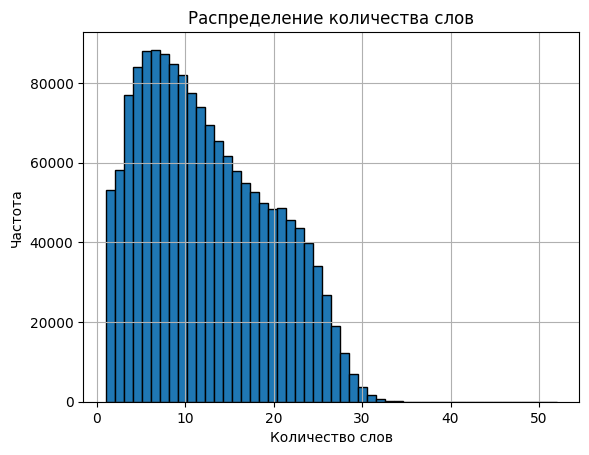

In [7]:
words_count = np.array([len(line.split()) for line in dataset])

print(f'Всего примеров: {len(dataset)}')
print('Статистика по количеству строк:')
print(f'Среднее: {np.mean(words_count):.2f}')
print(f'Медиана: {np.median(words_count):.2f}')
print(f'5%: {np.percentile(words_count, 5):.2f}')
print(f'95%: {np.percentile(words_count, 95):.2f}')

plt.hist(words_count, bins=50, edgecolor='black')
plt.title("Распределение количества слов")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

Большинство данных имеет от 3 до 26 слов, что позволит использовать несложные RNN

# Data Preparation

In [8]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# чтобы не добавлять новых токенов, будем считать CLS за начало фразы, SEP за конец
special_tokens = tokenizer.special_tokens_map
BOS_TOKEN_ID = tokenizer.convert_tokens_to_ids(special_tokens['cls_token'])
EOS_TOKEN_ID = tokenizer.convert_tokens_to_ids(special_tokens['sep_token'])
PAD_TOKEN_ID = tokenizer.convert_tokens_to_ids(special_tokens['pad_token'])


In [9]:
print('Creating train dataset')
train_dataset = NextTokenDataset(
    train_data,
    tokenizer,
    max_output_length=MAX_SEQ_LENGTH,
    split_num=config['dataset']['train_set_split_num']
)

# для валидации и теста три четверти текста - промпт, четверть - таргет
print('Creating val dataset')
val_dataset = NextTokenDataset(
    val_data,
    tokenizer,
    max_output_length=MAX_SEQ_LENGTH,
    split_num=1
)
print('Creating test dataset')
test_dataset = NextTokenDataset(
    test_data,
    tokenizer,
    max_output_length=MAX_SEQ_LENGTH,
    split_num=1
)

batch_size = config['train']['batch_size']

train_loader = next_token_data_loader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = next_token_data_loader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = next_token_data_loader(test_dataset, batch_size=batch_size, shuffle=False)

Creating train dataset


100%|██████████| 1000/1000 [00:00<00:00, 12612.10it/s]


Creating val dataset


100%|██████████| 1000/1000 [00:00<00:00, 17016.61it/s]


Creating test dataset


100%|██████████| 1000/1000 [00:00<00:00, 17949.08it/s]


# Training

In [10]:
def save_model(model, run_id, epoch):
    filename = f'{run_id}-{device}-{epoch}.pth'
    torch.save(model.state_dict(), os.path.join(MODEL_DIR, filename))

def print_random_predictions(model, data_loader, num):
    model.eval()

    batch = next(iter(data_loader))

    random_ints = torch.randint(low=0, high=batch['heads'].size(0), size=(num,))
    index = random_ints.tolist()

    input_ids = batch['heads'][index, :]
    target_ids = batch['tails'][index, :]

    prediction_ids = model.generate(input_ids, max_new_tokens=MAX_SEQ_LENGTH)

    inputs = tokenizer.batch_decode(input_ids, skip_special_tokens=True)
    targets = tokenizer.batch_decode(target_ids, skip_special_tokens=True)
    predictions = tokenizer.batch_decode(prediction_ids, skip_special_tokens=True)

    for inp, tgt, pred, ids in zip(inputs, targets, predictions, prediction_ids):
        print(f'Prompt: {inp}')
        print(f'Target: {tgt}')
        print(f'Prediction: {pred}')
        print(f'Prediction: {ids}\n')

Для часто встречающихся токенов снизим вес для loss функции, иначе модель упирается и предсказывает только их

In [26]:

token_cnt = Counter()
for line in train_data:
    token_ids  = tokenizer.encode(line, add_special_tokens=False)
    token_cnt.update(token_ids)

frequent_tokens = [id for id, _ in token_cnt.most_common(25)]

weights = torch.ones((tokenizer.vocab_size, ))

for id in frequent_tokens:
    weights[id] = 0.1

weights[PAD_TOKEN_ID] = 1e-10
weights[BOS_TOKEN_ID] = 1e-10
weights[EOS_TOKEN_ID] = 1e-10

print('Frequent tokens:')
print(tokenizer.decode(frequent_tokens))

token_cnt.total()

Frequent tokens:
i ' to the a my you it and is for tt s in on me so that of at have but ms


15063

In [20]:
model = seq2seq_model.NextTokenGenerator(
    tokenizer.vocab_size,
    hidden_dim=config['model']['hidden_dim']
)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN_ID, weight=weights)
optimizer = Adam(model.parameters(), lr=1e-3)
trainer = train_utils.Seq2SeqTrainer()

In [13]:
now = datetime.datetime.now()
run_id = f'seq2seq_weights-{now.strftime('%Y%m%d_%H%M%S')}'

task_config = {
    'run_id': run_id,
    'device': device,
    'dataset_size': len(train_dataset),
    'batch_size': config['train']['batch_size'],
    'epochs': config['train']['max_epoch'],
    'hidden size': config['model']['hidden_dim'],
}



100%|██████████| 16/16 [00:00<00:00, 35.26it/s]


Epoch 1, Train Loss: 9.5153, Val Loss: 8.1547, rouge score: 0.0
Prediction example:
Prompt: has finished his night shift and is nw off to bed should i have
Target: a beer tho before hand
Prediction: ##sssss
Prediction: tensor([2015, 2015, 2015, 2015, 2015])



100%|██████████| 16/16 [00:00<00:00, 36.01it/s]


Epoch 2, Train Loss: 7.3287, Val Loss: 8.1149, rouge score: 0.011232352237377367
Prediction example:
Prompt: is there any service that keeps track of the services
Target: available for twitter
Prediction: ##s days days
Prediction: tensor([2015, 2154, 2015, 2154, 2015])



100%|██████████| 16/16 [00:00<00:00, 36.13it/s]


...

Epoch 8, Train Loss: 6.8625, Val Loss: 8.4481, rouge score: 0.011363962670495331
Prediction example:
Prompt: i saw the movie quot up quot
Target: it was nice
Prediction: ##ss at but at
Prediction: tensor([2015, 2015, 2012, 2021, 2012])



100%|██████████| 16/16 [00:00<00:00, 35.72it/s]


Epoch 9, Train Loss: 6.8070, Val Loss: 8.4280, rouge score: 0.005125628140703518
Prediction example:
Prompt: john i think it ' s awesome that you ' re an inspiration figure for education keep up the good
Target: work in both music and
Prediction: ##ssss but
Prediction: tensor([2015, 2015, 2015, 2015, 2021])



100%|██████████| 16/16 [00:00<00:00, 36.20it/s]


Epoch 10, Train Loss: 6.7343, Val Loss: 8.4631, rouge score: 0.00580322246151392
Prediction example:
Prompt: is there any service that keeps track of the services
Target: available for twitter
Prediction: ##sss but but
Prediction: tensor([2015, 2015, 2015, 2021, 2021])



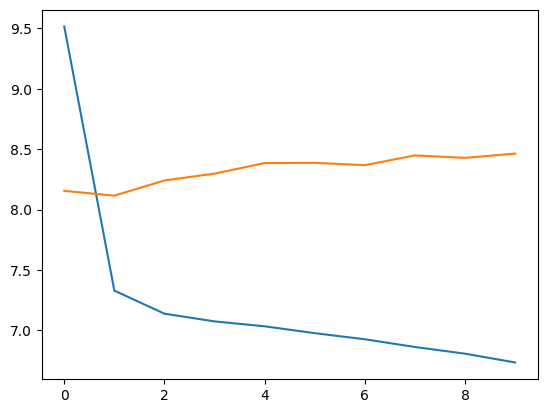

In [21]:
model.to(device)

all_train = []
all_val = []

with monitoring.ClearMLTask(project_name='RNN Autocomplete', task_name='Seq2seq2 model', task_config=task_config) as task:
    for epoch in range(config['train']['max_epoch']):
        train_loss, val_loss = train_utils.train_val_cycle(
            train_data=train_loader,
            val_data=val_loader,
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            trainer=trainer,
            device=device
        )

        rouge1 = 0
        rouge1, _ = model_scoring.score_model(model, val_loader, tokenizer, max_new_tokens=MAX_SEQ_LENGTH, device=device)

        task.report_scalar('Loss', 'train', train_loss, epoch)
        task.report_scalar('Loss', 'validate', val_loss, epoch)
        
        task.report_scalar('Rouge', 'validate', val_loss, epoch)

        all_train.append(train_loss)
        all_val.append(val_loss)
        
        print(f'Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, rouge score: {rouge1}')

        model.eval()
        print('Prediction example:')
        print_random_predictions(model, val_loader, 1)

        # начиная с десятой эпохи сохраняем промежуточные веса
        # если эпох меньше 10, то сохраним только последнее состояние
        if (epoch >= 9) or (epoch == config['train']['max_epoch'] - 1):
            save_model(model, run_id, epoch + 1)

plt.plot(all_train, label='train')
plt.plot(all_val, label='val')


# Примеры сгенерированных текстов

In [ ]:
generator = pipeline('text-generation', model='distilgpt2')

batch = next(iter(test_loader))

random_ints = torch.randint(low=0, high=batch['heads'].size(0), size=(3,))
index = random_ints.tolist()

input_ids = batch['heads'][index, :]
target_ids = batch['tails'][index, :]

prompts = tokenizer.batch_decode(input_ids, skip_special_tokens=True)
targets = tokenizer.batch_decode(target_ids, skip_special_tokens=True)

seq2seq_predictions = model.generate(input_ids, max_new_tokens=MAX_SEQ_LENGTH)
seq2seq_predictions = tokenizer.batch_decode(seq2seq_predictions, skip_special_tokens=True)

generator_predictions = generator(prompts, max_new_tokens=MAX_SEQ_LENGTH, pad_token_id=PAD_TOKEN_ID, )
generator_predictions = [line[0]['generated_text'].strip() for line in generator_predictions]

for i in range(3):
    print(f'Example {i + 1}:')
    print(f'Prompt: {prompts[i]}')
    print(f'Target: {targets[i]}')
    print(f'Predicted by model: {seq2seq_predictions[i]}')
    print(f'Predicted by transformer: {generator_predictions[i]}\n')


Device set to use mps:0


[{'generated_text': 'feels for her friend and wants to make her all better wish i could not get off the ground'}, {'generated_text': 'rawr i have like an idea for how the'}, {'generated_text': 'going to bed now goodnight everyone i hope to be able to do'}]
Example 1:
Prompt: feels for her friend and wants to make her all better wish i could
Target: make it go away
Predicted by model: m m m m m
Predicted by transformer: feels for her friend and wants to make her all better wish i could not get off the ground

Example 2:
Prompt: rawr i have like
Target: no voice
Predicted by model: m m m m m
Predicted by transformer: rawr i have like an idea for how the

Example 3:
Prompt: going to bed now goodnight everyone i hope
Target: tomorrow goes well
Predicted by model: m m m m m
Predicted by transformer: going to bed now goodnight everyone i hope to be able to do



# Финальная оценка всех моделей

Используется test датасет

In [ ]:
# final_metrics = {}
final_metrics = {
    'seq2seq': model_scoring.score_model(model, train_loader, tokenizer, max_new_tokens=MAX_SEQ_LENGTH, device=device),
    'transformer': model_scoring.score_transformer('distilgpt2', val_loader, tokenizer, max_length=MAX_SEQ_LENGTH)
}

In [17]:
print(f'{'Model':<12} | {'ROUGE1':<6} | {'ROUGE2':<6}')
print('-' * 35)
for model_name, (rouge1, rouge2) in final_metrics.items():
    print(f'{model_name:<12} | {rouge1:.4f} | {rouge2:.4f}')

Model        | ROUGE1 | ROUGE2
-----------------------------------
